# Rae2822 2D Wing Slice Model

### Import Library

In [63]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

### Loading Data

In [64]:
angles = range(21)

folder_path = "./data/rae2822/angvar_sa/"

files = sorted(glob.glob(f"{folder_path}*/surface_flow.csv"))

master_df = []

for i, filename in enumerate(files):
    df = pd.read_csv(filename)

    # apply angles for each case
    df['AoA'] = angles[i]

    master_df.append(df)

# Combine into one training set
full_data = pd.concat(master_df, ignore_index=True)

In [65]:
print(f"Total rows: {len(full_data)}")
full_data.head()

Total rows: 4032


,PointID,x,y,Density,Momentum_x,Momentum_y,Energy,Nu_Tilde,Pressure,Temperature,Mach,Pressure_Coefficient,Laminar_Viscosity,Skin_Friction_Coefficient_x,Skin_Friction_Coefficient_y,Heat_Flux,Y_Plus,Eddy_Viscosity,AoA
0,25,0.985397,0.000943,0.467747,0.0,0.0,106411.802258,0.0,42564.720903,317.006918,0.0,0.262408,0.000019,0.002042,-8.852195e-05,-175.102208,2.161991,0.0,0
1,51,0.969573,0.001489,0.470406,0.0,0.0,107034.099699,0.0,42813.639880,317.058955,0.0,0.279663,0.000019,0.001661,-3.739569e-05,-75.599800,1.954830,0.0,0
2,77,0.952680,0.001679,0.472434,0.0,0.0,107515.203056,0.0,43006.081222,317.116347,0.0,0.293002,0.000019,0.001458,-9.411266e-07,-43.903973,1.834732,0.0,0
3,103,0.934996,0.001511,0.472826,0.0,0.0,107615.419162,0.0,43046.167665,317.149233,0.0,0.295781,0.000019,0.001345,2.838548e-05,-31.992952,1.763323,0.0,0
4,129,0.916822,0.000923,0.472299,0.0,0.0,107499.088533,0.0,42999.635413,317.159465,0.0,0.292556,0.000019,0.001284,5.265905e-05,-27.650354,1.722190,0.0,0


### Model

In [66]:
# Train test split Leave-one-out
# We only have 4000 row of data
# to prevent model cheating (Data Leakage) 
# we use leave-one-out method to test model on unseen data
hidden_aoa = 5.0

train_data = full_data[full_data['AoA'] != hidden_aoa]
test_data = full_data[full_data['AoA'] == hidden_aoa]

X_train = train_data[['x', 'y', 'AoA']]
y_train = train_data['Pressure_Coefficient']

X_test = test_data[['x', 'y', 'AoA']]
y_test = test_data['Pressure_Coefficient']

In [67]:
Random_forest = RandomForestRegressor(n_estimators=100, random_state=42, oob_score=True)
Random_forest.fit(X_train, y_train)

predictions = Random_forest.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)
oob_score = Random_forest.oob_score_
mse = mean_squared_error(y_test, predictions)


print(f"--- BLIND TEST RESULTS FOR AoA {hidden_aoa}° ---")
print(f"Real RMSE: {rmse:.5f}")
print(f'Mean Squared Error: {mse}')
print(f"Real R-squared: {r2:.5f}")
print(f'Out-of-Bag Score: {oob_score}')


--- BLIND TEST RESULTS FOR AoA 5.0° ---
Real RMSE: 0.07006
Mean Squared Error: 0.004908561975193464
Real R-squared: 0.98741
Out-of-Bag Score: 0.9891325052196673


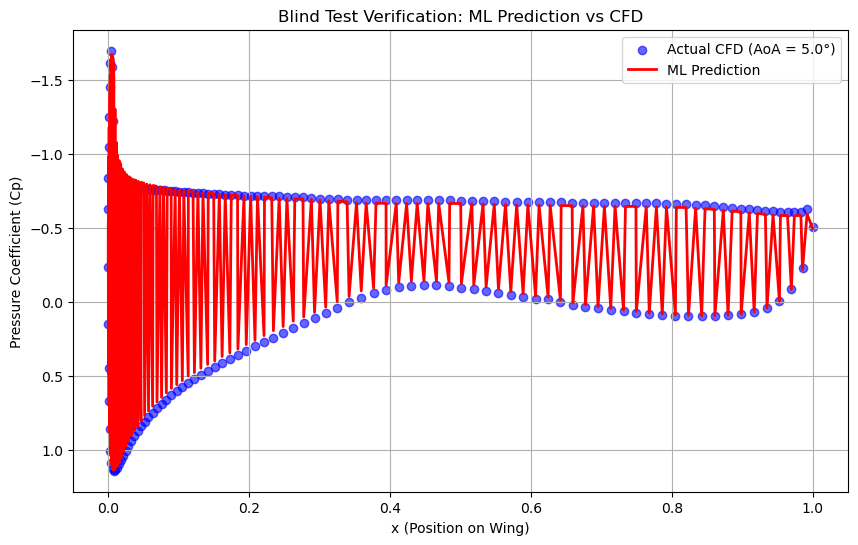

In [77]:
# Sort the test data by x so the lines draw smoothly
X_test_sorted = X_test.sort_values(by='x')

# We also have to sort our predictions to match the sorted X_test
sorted_indices = X_test['x'].argsort()
predictions_sorted = predictions[sorted_indices]
y_test_sorted = y_test.iloc[sorted_indices]

plt.figure(figsize=(10, 6))

# Plot Actual CFD (Blue Dots)
plt.scatter(X_test_sorted['x'], y_test_sorted, color='blue', label='Actual CFD (AoA = 5.0°)', alpha=0.6)

# Plot ML Prediction (Red Line)
plt.plot(X_test_sorted['x'], predictions_sorted, color='red', linewidth=2, label='ML Prediction')

plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
plt.title("Blind Test Verification: ML Prediction vs CFD")
plt.xlabel("x (Position on Wing)")
plt.ylabel("Pressure Coefficient (Cp)")
plt.legend()
plt.grid(True)
plt.show()

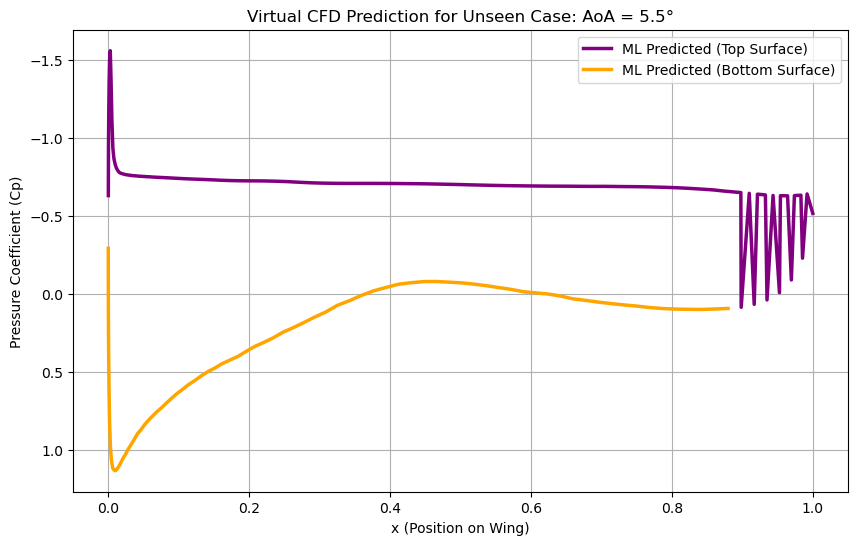

In [79]:
# --- 1. BUILD THE INPUT DATA ---
# Grab the rigid wing shape (x and y) from ANY existing case (like Case 0)
# We just need those 192 rows that define the RAE2822 airfoil.
new_case = full_data[full_data['AoA'] == 0.0][['x', 'y']].copy()

# Inject our brand new physics condition
new_case['AoA'] = 5.5 

# --- 2. RUN THE ML SOLVER ---
# Notice we are feeding it the exact same columns: ['x', 'y', 'AoA']
# This happens in 0.01 seconds! (No 5,000 iterations required)
predicted_cp = Random_forest.predict(new_case[['x', 'y', 'AoA']])

# Attach the answers back to our dataframe
new_case['Predicted_Cp'] = predicted_cp

# --- 3. PLOT THE DISCOVERY ---
plt.figure(figsize=(10, 6))

# Split the wing into Top and Bottom so the lines draw smoothly without zig-zags
top_surface = new_case[new_case['y'] > 0].sort_values(by='x')
bottom_surface = new_case[new_case['y'] <= 0].sort_values(by='x')

# Draw the Predicted Curves
plt.plot(top_surface['x'], top_surface['Predicted_Cp'], color='purple', linewidth=2.5, label='ML Predicted (Top Surface)')
plt.plot(bottom_surface['x'], bottom_surface['Predicted_Cp'], color='orange', linewidth=2.5, label='ML Predicted (Bottom Surface)')

plt.gca().invert_yaxis() # Invert y-axis for Aerodynamics
plt.title("Virtual CFD Prediction for Unseen Case: AoA = 5.5°")
plt.xlabel("x (Position on Wing)")
plt.ylabel("Pressure Coefficient (Cp)")
plt.legend()
plt.grid(True)
plt.show()